In [1]:
import os

print(os.getcwd())
print(os.listdir('../Data'))

/home/claude/work/Notebooks
['traffic_cleaned.parquet', 'y_train_cls.pkl', 'y_test_cls.pkl', 'X_train_reg.pkl', 'traffic_feature_engineered.parquet', 'y_train_reg.pkl', 'X_test_reg.pkl', 'y_test_reg.pkl', 'X_train_cls.pkl', 'Metro_Interstate_Traffic_Volume_modified.csv', 'X_test_cls.pkl']


In [2]:
import pandas as pd
import numpy as np
import joblib

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Selection
from sklearn.model_selection import RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
import joblib

X_train = joblib.load('../Data/X_train_cls.pkl')
X_test = joblib.load('../Data/X_test_cls.pkl')

y_train = joblib.load('../Data/y_train_cls.pkl')
y_test = joblib.load('../Data/y_test_cls.pkl')

In [4]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [5]:
print("Original Classes:")
print(label_encoder.classes_)

print("\nEncoded Training Target:")
print(np.unique(y_train_encoded))

print("\nEncoded Test Target:")
print(np.unique(y_test_encoded))

Original Classes:
['High' 'Low' 'Medium']

Encoded Training Target:
[0 1 2]

Encoded Test Target:
[0 1 2]


In [6]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (38257, 66)
X_test: (7537, 66)
y_train: (38257,)
y_test: (7537,)


In [7]:
print("Training Target Distribution:")
print(y_train.value_counts())

print("\nTest Target Distribution:")
print(y_test.value_counts())

Training Target Distribution:
congestion_level
High      12755
Low       12754
Medium    12748
Name: count, dtype: int64

Test Target Distribution:
congestion_level
Medium    2517
Low       2512
High      2508
Name: count, dtype: int64


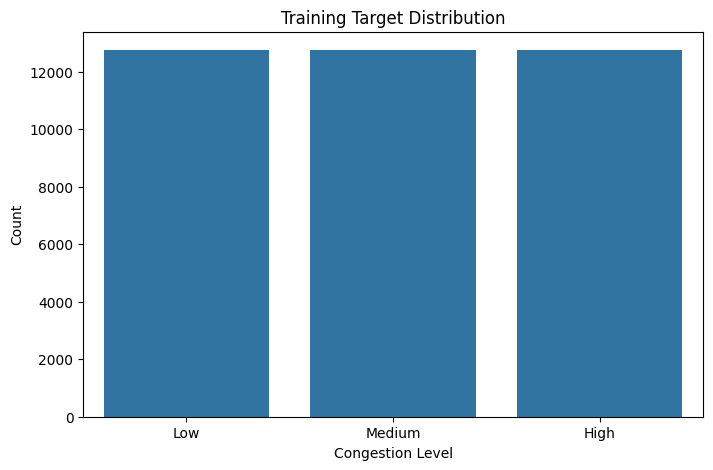

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(x=y_train)

plt.title("Training Target Distribution")
plt.xlabel("Congestion Level")
plt.ylabel("Count")

plt.show()

# Baseline Model

In [9]:
baseline_class = y_train.value_counts().idxmax()

baseline_predictions = np.full(
    len(y_test),
    baseline_class
)

In [10]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.3327583919331299


In [11]:
def evaluate_classification_model(model, X_train, y_train, X_test, y_test):
    
    # Train
    model.fit(X_train, y_train)
    
    # Prediction
    y_pred = model.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    
    precision = precision_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )
    
    recall = recall_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )
    
    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted',
        zero_division=0
    )
    
    return {
        'Model': model.__class__.__name__,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

# Logistic Regression

In [12]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Decision Tree

In [13]:
dt = DecisionTreeClassifier(
    random_state=42
)

# Random Forest

In [14]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# XGBoost

In [15]:
xgb = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)

In [16]:
models = [
    log_reg,
    dt,
    rf,
    xgb
]

In [17]:
classification_results = []

for model in models:
    
    result = evaluate_classification_model(
        model,
        X_train,
        y_train_encoded,
        X_test,
        y_test_encoded
    )
    
    classification_results.append(result)

In [18]:
results_classification = pd.DataFrame(
    classification_results
)

results_classification

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.765689,0.760971,0.765689,0.762374
1,DecisionTreeClassifier,0.854717,0.857405,0.854717,0.855670
2,RandomForestClassifier,0.890142,0.891851,0.890142,0.890320
3,XGBClassifier,0.898103,0.899842,0.898103,0.898366


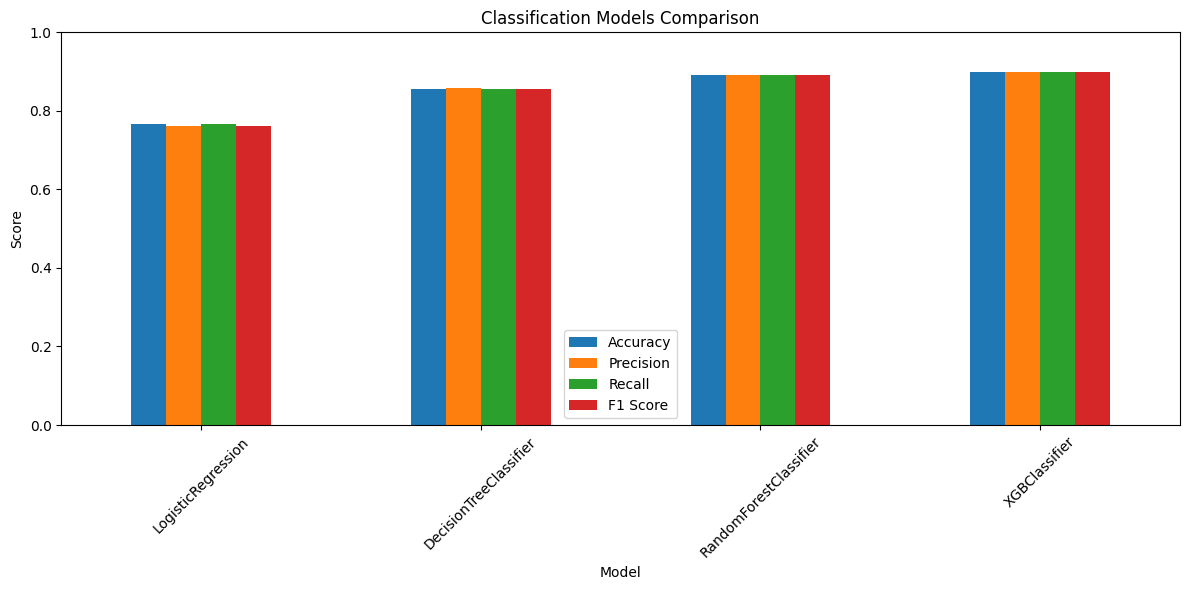

In [19]:
results_classification.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Classification Models Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [20]:
best_model = xgb

best_model.fit(X_train, y_train_encoded)

y_pred = best_model.predict(X_test)

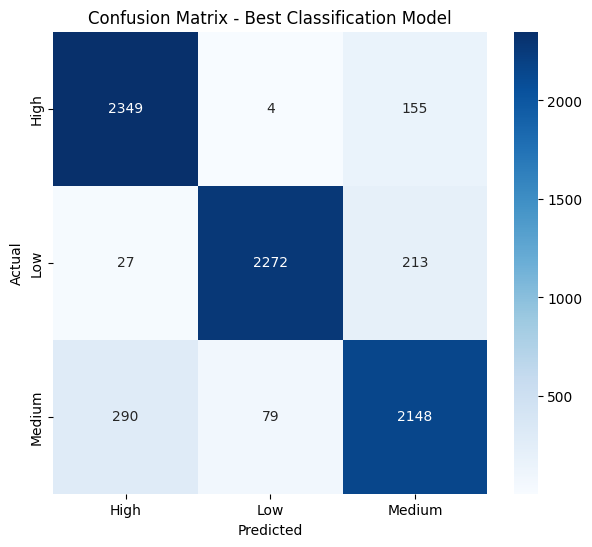

In [21]:
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Best Classification Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.88      0.94      0.91      2508
         Low       0.96      0.90      0.93      2512
      Medium       0.85      0.85      0.85      2517

    accuracy                           0.90      7537
   macro avg       0.90      0.90      0.90      7537
weighted avg       0.90      0.90      0.90      7537



In [23]:
pd.DataFrame(classification_results)

,Model,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.765689,0.760971,0.765689,0.762374
1,DecisionTreeClassifier,0.854717,0.857405,0.854717,0.855670
2,RandomForestClassifier,0.890142,0.891851,0.890142,0.890320
3,XGBClassifier,0.898103,0.899842,0.898103,0.898366


# Tuning

In [24]:
from sklearn.model_selection import RandomizedSearchCV

In [25]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

In [26]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [27]:
random_search.fit(
    X_train,
    y_train_encoded
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can b

In [28]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'subsample': 0.7, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [29]:
print("Best CV Score:")
print(random_search.best_score_)

Best CV Score:
0.8872690468965129


In [30]:
best_xgb = random_search.best_estimator_
best_xgb_cls = best_xgb

In [31]:
import joblib

joblib.dump(
    best_xgb_cls,
    '../Models/best_xgb_cls.pkl'
)

['../Models/best_xgb_cls.pkl']

In [32]:
joblib.dump(
    label_encoder,
    '../Models/classification_label_encoder.pkl'
)

['../Models/classification_label_encoder.pkl']

In [33]:
y_pred_tuned = best_xgb.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_tuned = accuracy_score(
    y_test_encoded,
    y_pred_tuned
)

precision_tuned = precision_score(
    y_test_encoded,
    y_pred_tuned,
    average='weighted'
)

recall_tuned = recall_score(
    y_test_encoded,
    y_pred_tuned,
    average='weighted'
)

f1_tuned = f1_score(
    y_test_encoded,
    y_pred_tuned,
    average='weighted'
)

print("Tuned XGBoost Results")
print("---------------------")
print("Accuracy :", accuracy_tuned)
print("Precision:", precision_tuned)
print("Recall   :", recall_tuned)
print("F1 Score :", f1_tuned)

Tuned XGBoost Results
---------------------
Accuracy : 0.8969085843173676
Precision: 0.8988839214197634
Recall   : 0.8969085843173676
F1 Score : 0.8968122466253371


In [35]:
comparison = pd.DataFrame({
    'Model': [
        'XGBoost Before Tuning',
        'XGBoost After Tuning'
    ],
    
    'Accuracy': [
        0.898103,
        accuracy_tuned
    ],
    
    'Precision': [
        0.899842,
        precision_tuned
    ],
    
    'Recall': [
        0.898103,
        recall_tuned
    ],
    
    'F1 Score': [
        0.898366,
        f1_tuned
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost Before Tuning,0.898103,0.899842,0.898103,0.898366
1,XGBoost After Tuning,0.896909,0.898884,0.896909,0.896812


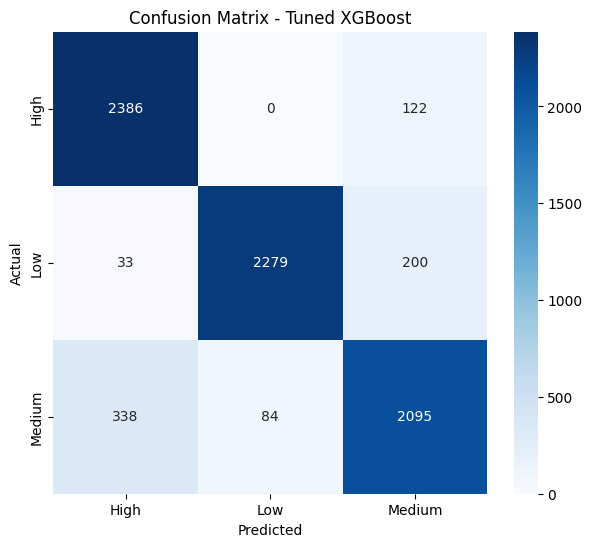

In [36]:
cm_tuned = confusion_matrix(
    y_test_encoded,
    y_pred_tuned
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [37]:
print(
    classification_report(
        y_test_encoded,
        y_pred_tuned,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.87      0.95      0.91      2508
         Low       0.96      0.91      0.93      2512
      Medium       0.87      0.83      0.85      2517

    accuracy                           0.90      7537
   macro avg       0.90      0.90      0.90      7537
weighted avg       0.90      0.90      0.90      7537



In [38]:
final_classification_model = best_xgb

In [39]:
y_pred_final = final_classification_model.predict(X_test)

In [40]:
print(
    classification_report(
        y_test_encoded,
        y_pred_final,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

        High       0.87      0.95      0.91      2508
         Low       0.96      0.91      0.93      2512
      Medium       0.87      0.83      0.85      2517

    accuracy                           0.90      7537
   macro avg       0.90      0.90      0.90      7537
weighted avg       0.90      0.90      0.90      7537



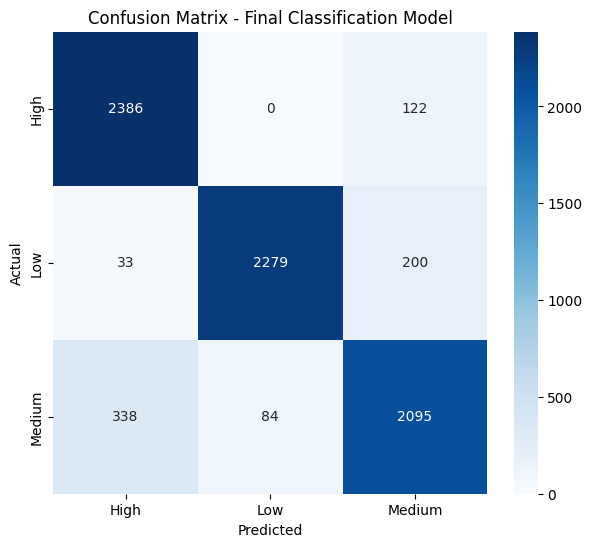

In [41]:
cm_final = confusion_matrix(
    y_test_encoded,
    y_pred_final
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Final Classification Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()